# Simulation of emittance measurement using project formulas and other approaches

In [1]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, minimize


RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


# Bunch parameters

In [2]:
# Bunch parameters
mass = rft.electronmass # MeV / c^2
charge=-1 # single particle charge, in units of e
population = 1 * rft.nC # number of real particles per bunch
Pref = 100 # reference momentum, MeV / c
P_Q = Pref / charge # MV / c, reference rigidity

# Creating an essential beam line

In [3]:
Lquad = 0.20 # m
LQ0 = 0.40 # drifts between each screen, m
L01 = 0.80
L12 = 0.80
L23 = 0.80

K1L_nom = -2.5 # 1/m2
strength_nom = K1L_nom * P_Q

Q = rft.Quadrupole(Lquad, strength_nom)
DQ0 = rft.Drift(LQ0)
D01 = rft.Drift(L01)
D12 = rft.Drift(L12)
D23 = rft.Drift(L23)

for D in (DQ0, D01, D12, D23):
    D.set_tt_nsteps(100) # number of steps for the transport table

SCR0 = rft.Screen()
SCR1 = rft.Screen()
SCR2 = rft.Screen()
SCR3 = rft.Screen()

Beamline = rft.Lattice()
Beamline.append(Q)
Beamline.append(DQ0)
Beamline.append(SCR0)
Beamline.append(D01)
Beamline.append(SCR1)
Beamline.append(D12)
Beamline.append(SCR2)
Beamline.append(D23)
Beamline.append(SCR3)

screen_names = ["SCR0", "SCR1", "SCR2", "SCR3"]
L_downstream = np.array([0.0, L01, L01 + L12, L01 + L12 + L23], dtype=float)

# Creating a bunch and specifying the Twiss parameters and emittance that we want to reconstruct

In [4]:
base = {
    "emitt_x": 5.2,  # mm.mrad normalized
    "emitt_y": 0.03,  # mm.mrad normalized
    "beta_x": 6.3,
    "beta_y": 6.2,
    "alpha_x": -4.5,
    "alpha_y": 2.55,
}

Nparticles = 10000

def make_twiss_from_dict(dict):
    T = rft.Bunch6d_twiss()
    T.emitt_x = float(dict["emitt_x"])
    T.emitt_y = float(dict["emitt_y"])
    T.beta_x = float(dict["beta_x"])
    T.beta_y = float(dict["beta_y"])
    T.alpha_x = float(dict["alpha_x"])
    T.alpha_y = float(dict["alpha_y"])
    return T

def make_bunch(dict, nparticles = Nparticles):
    T = make_twiss_from_dict(dict)
    return rft.Bunch6d(mass, population, charge, Pref, T, nparticles)

def scan_quadrupole(K1L_value):
    Beamline[0].set_K1L(abs(P_Q), float(K1L_value))

def phase_space_sigmas(B):
    M = B.get_phase_space('%x %y')
    x = np.asarray(M[:, 0], dtype=float)
    y = np.asarray(M[:, 1], dtype=float)
    mx = np.mean(x)
    my = np.mean(y)
    vx = np.mean(x ** 2) - mx ** 2
    vy = np.mean(y ** 2) - my ** 2
    return {
        "sigma_x": np.sqrt(max(vx, 0.0)),
        "sigma_y": np.sqrt(max(vy, 0.0)),
        "sigma2_x": vx,
        "sigma2_y": vy,
        "mean_x": mx,
        "mean_y": my,
    }

def track_and_get_values(dict, K1L_value, nparticles = Nparticles):
    scan_quadrupole(K1L_value)
    B0 = make_bunch(dict, nparticles)
    Beamline.track(B0)
    screen_bunches = Beamline.get_bunch_at_screens()

    sigx = []
    sigy = []
    sigx2 = []
    sigy2 = []
    meanx = []
    meany = []

    for B in screen_bunches:
        output = phase_space_sigmas(B)
        sigx.append(output["sigma_x"])
        sigy.append(output["sigma_y"])
        sigx2.append(output["sigma2_x"])
        sigy2.append(output["sigma2_y"])
        meanx.append(output["mean_x"])
        meany.append(output["mean_y"])

    return {
        "sigx": np.asarray(sigx, dtype=float),
        "sigy": np.asarray(sigy, dtype=float),
        "sigx2": np.asarray(sigx2, dtype=float),
        "sigy2": np.asarray(sigy2, dtype=float),
        "meanx": np.asarray(meanx, dtype=float),
        "meany": np.asarray(meany, dtype=float),
    }

def get_scan_response(dict, K1L_values, nparticles = Nparticles):
    sigx = []
    sigy = []
    sigx2 = []
    sigy2 = []
    for K in K1L_values:
        out = track_and_get_values(dict, K, nparticles=nparticles)
        sigx.append(out["sigx"])
        sigy.append(out["sigy"])
        sigx2.append(out["sigx2"])
        sigy2.append(out["sigy2"])
    return {
        "K1L_values": np.asarray(K1L_values, dtype=float),
        "sigx": np.asarray(sigx, dtype=float),
        "sigy": np.asarray(sigy, dtype=float),
        "sigx2": np.asarray(sigx2, dtype=float),
        "sigy2": np.asarray(sigy2, dtype=float),
    }

def gamma_from_twiss(beta,alpha):
    return (1.0 + alpha**2) / beta

# Performing quadrupole scan by varying its strength and fitting the parameters

In [5]:
K1L_values = np.linspace(K1L_nom - 1.5, K1L_nom + 1.5, 25)
scan_vals = get_scan_response(base, K1L_values , nparticles=Nparticles)

sigx_0 = scan_vals["sigx"]
sigy_0 = scan_vals["sigy"]
sigx2_0 = scan_vals["sigx2"]
sigy2_0 = scan_vals["sigy2"]

# Emittance preservation check

Columns: S, sigma_x, sigma_y, emitt_x, emitt_y, beta_x, beta_y, alpha_x, alpha_y
[[ 0.00000000e+00  4.08847014e-01  3.06087672e-02 ...  6.11153657e+00
  -4.49423555e+00  2.52206401e+00]
 [ 2.00000000e-01  3.64689615e-01  3.58595189e-02 ...  8.38817831e+00
   9.81285173e+00 -1.57421022e+01]
 [ 2.04000000e-01  3.61829804e-01  3.61287133e-02 ...  8.51458973e+00
   9.73509930e+00 -1.58607519e+01]
 ...
 [ 3.00000000e+00  1.64992207e+00  2.24611959e-01 ...  3.29097430e+02
  -4.46138459e+01 -9.87969162e+01]
 [ 3.00000000e+00  1.64992207e+00  2.24611959e-01 ...  3.29097430e+02
  -4.46138459e+01 -9.87969162e+01]
 [ 3.00000000e+00  1.64992207e+00  2.24611959e-01 ...  3.29097430e+02
  -4.46138459e+01 -9.87969162e+01]]


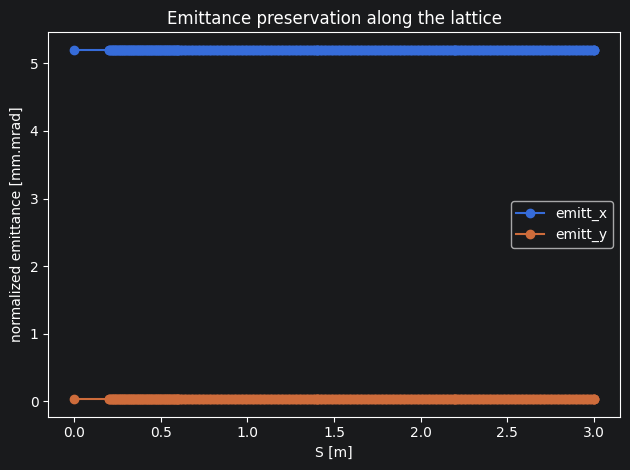

In [6]:
scan_quadrupole(K1L_nom)
B_nom = make_bunch(base, nparticles=Nparticles)
Beamline.track(B_nom)
Ttab = Beamline.get_transport_table('%S %sigma_x %sigma_y %emitt_x %emitt_y %beta_x %beta_y %alpha_x %alpha_y')

print("Columns: S, sigma_x, sigma_y, emitt_x, emitt_y, beta_x, beta_y, alpha_x, alpha_y")
print(Ttab)

plt.figure()
plt.plot(Ttab[:, 0], Ttab[:, 3], 'o-', label='emitt_x')
plt.plot(Ttab[:, 0], Ttab[:, 4], 'o-', label='emitt_y')
plt.xlabel('S [m]')
plt.ylabel('normalized emittance [mm.mrad]')
plt.title('Emittance preservation along the lattice')
plt.legend()
plt.tight_layout()
plt.show()

# 7. Current approach used in the Emittance Measurement application

The current code uses a **two-step approach**.

## Step 1 — optics / transport are determined first
At the reference screen, the optics are represented by
\[
\beta_0(K_k), \qquad \alpha_0(K_k), \qquad \gamma_0(K_k)=\frac{1+\alpha_0(K_k)^2}{\beta_0(K_k)}.
\]

In the real application these arrays come from the optics-measurement stage:
- `beta_step[k]`
- `alpha_step[k]`
- `gamma_step[k]`

and the downstream transport is represented by
- `transport_params[i] = (R_{11,i}, R_{12,i})`.

## Step 2 — fit the emittance only
Once the optics and transport are fixed, the beam matrix at the reference screen is
\[
\Sigma_0(K_k)=
\varepsilon
\begin{pmatrix}
\beta_0(K_k) & -\alpha_0(K_k) \\
-\alpha_0(K_k) & \gamma_0(K_k)
\end{pmatrix}.
\]

For each downstream screen, the propagated beam matrix is
\[
\Sigma_i(K_k)=R_i\,\Sigma_0(K_k)\,R_i^T,
\]
with
\[
R_i=
\begin{pmatrix}
R_{11,i} & R_{12,i} \\
R_{21,i} & R_{22,i}
\end{pmatrix}.
\]

The measured beam size squared is the \((1,1)\) element of the propagated beam matrix,
\[
\sigma_i^2(K_k)=\Sigma^{(i)}_{11}(K_k)
=\varepsilon\left(R_{11,i}^2\beta_0(K_k)-2R_{11,i}R_{12,i}\alpha_0(K_k)+R_{12,i}^2\gamma_0(K_k)\right).
\]

For the reference screen itself, the code uses
\[
\sigma_0^2(K_k)=\varepsilon\,\beta_0(K_k).
\]

## What is measured and what is modelled here?
In the fit:
- the **measured** quantities are `sigx2_0[k, i]` and `sigy2_0[k, i]`, i.e. the beam-size-squared values obtained from the simulated screens for each quadrupole setting and each screen,
- the **modelled** quantities are `pred[k, i]`, computed from the fixed optics arrays, the transport coefficients \(R_{11}, R_{12}\), and the fitted emittance.

## Merit function used in the current application-style fit
The final fit minimizes the weighted residuals
\[
r_{k,i}=\frac{\sigma^2_{\mathrm{model},k,i}-\sigma^2_{\mathrm{meas},k,i}}{\Delta\sigma^2_i},
\]
so the merit function is essentially a weighted least-squares / \(\chi^2\)-like quantity:
\[
\chi^2 = \sum_{k,i} r_{k,i}^2.
\]

In code, the "modelled" term is `pred`, the "measured" term is `sig2_meas`, and the scale of the residuals is `sigma_floor`.

## Role of \(\alpha\) in downstream propagation
The \(\alpha\) parameter appears in the mixed term
\[
-2R_{11,i}R_{12,i}\alpha_0(K_k).
\]
This means that \(\alpha\) controls the correlation between position and angle in the beam matrix. Downstream screen sizes are therefore affected not only by the beam-size term \(R_{11}^2\beta\) and the angular-spread term \(R_{12}^2\gamma\), but also by the position-angle correlation term proportional to \(\alpha\).

## Where do \(R_{11}\) and \(R_{12}\) come from in the project?
In the real application, these are taken from the transport model used by `MeasureOptics`.
In this notebook, they are set explicitly as a simple drift transport from the reference screen to the downstream screens:
\[
R_{11}=1, \qquad R_{12}=L,
\]
which is implemented below through:
- `R11 = np.ones(4, dtype=float)`
- `R12 = L_downstream.copy()`

So in this notebook, \(R_{11}\) and \(R_{12}\) are not fitted: they are provided as fixed transport inputs, exactly in the spirit of the final application stage.

In [7]:
beta_step_x = np.full_like(K1L_values, base["beta_x"], dtype=float)

alpha_step_x = np.full_like(K1L_values, base["alpha_x"], dtype=float)

gamma_step_x = gamma_from_twiss(beta_step_x, alpha_step_x)

beta_step_y = np.full_like(K1L_values, base["beta_y"], dtype=float)

alpha_step_y = np.full_like(K1L_values, base["alpha_y"], dtype=float)

gamma_step_y = gamma_from_twiss(beta_step_y, alpha_step_y)

screen_scale_params_x = np.ones(len(screen_names) - 1, dtype=float)

screen_scale_params_y = np.ones(len(screen_names) - 1, dtype=float)

transport_params = np.column_stack([R11[1:], R12[1:]])

def predict_sigma2_app_like(emit, beta_step, alpha_step, gamma_step, transport_params, screen_scale_params):

    nsteps = len(beta_step)

    nscreens = len(screen_names)

    pred = np.zeros((nsteps, nscreens), dtype=float)

    pred[:, 0] = emit * beta_step

    for i, row in enumerate(transport_params):

        R11_i, R12_i = row

        pred[:, i + 1] = emit * screen_scale_params[i] * (

            R11_i ** 2 * beta_step

            - 2.0 * R11_i * R12_i * alpha_step

            + R12_i ** 2 * gamma_step

        )

    return pred

def fit_plane_app_like(sig2_meas, plane_name, beta_step, alpha_step, gamma_step, transport_params, screen_scale_params):

    emit_guess = max(np.nanmedian(sig2_meas[:, 0] / np.maximum(beta_step, 1e-12)), 1e-12)

    sigma_floor = np.maximum(1e-8, 0.02 * np.nanmedian(sig2_meas, axis=0))

    def residuals(x):

        emit = float(np.exp(x[0]))

        pred = predict_sigma2_app_like(emit, beta_step, alpha_step, gamma_step, transport_params, screen_scale_params)

        return ((pred - sig2_meas) / sigma_floor[None, :]).ravel()

    fit = least_squares(residuals, np.array([np.log(emit_guess)], dtype=float), max_nfev=20000)

    emit = float(np.exp(fit.x[0]))

    pred = predict_sigma2_app_like(emit, beta_step, alpha_step, gamma_step, transport_params, screen_scale_params)

    resid_rms = np.sqrt(np.mean((pred - sig2_meas) ** 2))

    return {

        "fit": fit,

        "eps": emit,

        "beta0_nom": float(beta_step[len(beta_step) // 2]),

        "alpha0_nom": float(alpha_step[len(alpha_step) // 2]),

        "gamma0_nom": float(gamma_step[len(gamma_step) // 2]),

        "pred_sigma2": pred,

        "resid_rms": resid_rms,

        "plane": plane_name,

    }

results_x = fit_plane_app_like(

    sigx2_0,

    "x",

    beta_step_x,

    alpha_step_x,

    gamma_step_x,

    transport_params,

    screen_scale_params_x,

)

results_y = fit_plane_app_like(

    sigy2_0,

    "y",

    beta_step_y,

    alpha_step_y,

    gamma_step_y,

    transport_params,

    screen_scale_params_y,

)

print("Results of current application-style final fit")

print("x: eps =", results_x["eps"], "beta0 =", results_x["beta0_nom"], "alpha0 =", results_x["alpha0_nom"], "resid_rms =", results_x["resid_rms"])

print("y: eps =", results_y["eps"], "beta0 =", results_y["beta0_nom"], "alpha0 =", results_y["alpha0_nom"], "resid_rms =", results_y["resid_rms"])

Results of multi-screen fit
x: eps = 0.07512708783012748 beta0 = 0.25466786872437835 alpha0 = -0.36443593332292556 resid_rms = 0.20069086355266094
y: eps = 8.104866590950904e-06 beta0 = 492.00921229022924 alpha0 = -529.0018841523356 resid_rms = 0.00023355919004623257


# Plots

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
ax.plot(K1L_values, sigx2_0[:, 0], 'o', label=r'data $\sigma_x^2$(SCR0)')
xf = np.linspace(K1L_values.min(), K1L_values.max(), 300)
ax.plot(xf, fit_x_scr0["a"] * xf ** 2 + fit_x_scr0["b"] * xf + fit_x_scr0["c"], '-', label='quadratic fit')
ax.set_xlabel('K1L [1/m]')
ax.set_ylabel(r'$\sigma_x^2$ [mm$^2$]')
ax.legend()
ax.set_title('Single-screen inversion, x plane')

ax = axes[0, 1]
ax.plot(K1L_values, sigy2_0[:, 0], 'o', label=r'data $\sigma_y^2$(SCR0)')
yf = np.linspace(K1L_values.min(), K1L_values.max(), 300)
ax.plot(yf, fit_y_scr0["a"] * yf ** 2 + fit_y_scr0["b"] * yf + fit_y_scr0["c"], '-', label='quadratic fit')
ax.set_xlabel('K1L [1/m]')
ax.set_ylabel(r'$\sigma_y^2$ [mm$^2$]')
ax.legend()
ax.set_title('Single-screen inversion, y plane')

ax = axes[1, 0]
for i, sname in enumerate(screen_names):
    ax.plot(K1L_values, sigx2_0[:, i], 'o', ms=4)
    ax.plot(K1L_values, results_x["pred_sigma2"][:, i], '-', lw=1.5)
ax.set_xlabel('K1L [1/m]')
ax.set_ylabel(r'$\sigma_x^2$ [mm$^2$]')
ax.set_title('Project-style fit, x plane')

ax = axes[1, 1]
for i, sname in enumerate(screen_names):
    ax.plot(K1L_values, sigy2_0[:, i], 'o', ms=4)
    ax.plot(K1L_values, results_y["pred_sigma2"][:, i], '-', lw=1.5)
ax.set_xlabel('K1L [1/m]')
ax.set_ylabel(r'$\sigma_y^2$ [mm$^2$]')
ax.set_title('Project-style fit, y plane')

plt.tight_layout()
plt.show()